数据尺寸: (11520, 15) 
数据起点: 0
训练集尺寸: (10368, 15)
测试集尺寸: (1152, 15)

正在进行 CEEMDAN 分解用于可视化测试 (取前 800 个点)...
该片段共分解出 8 个 IMF 分量。


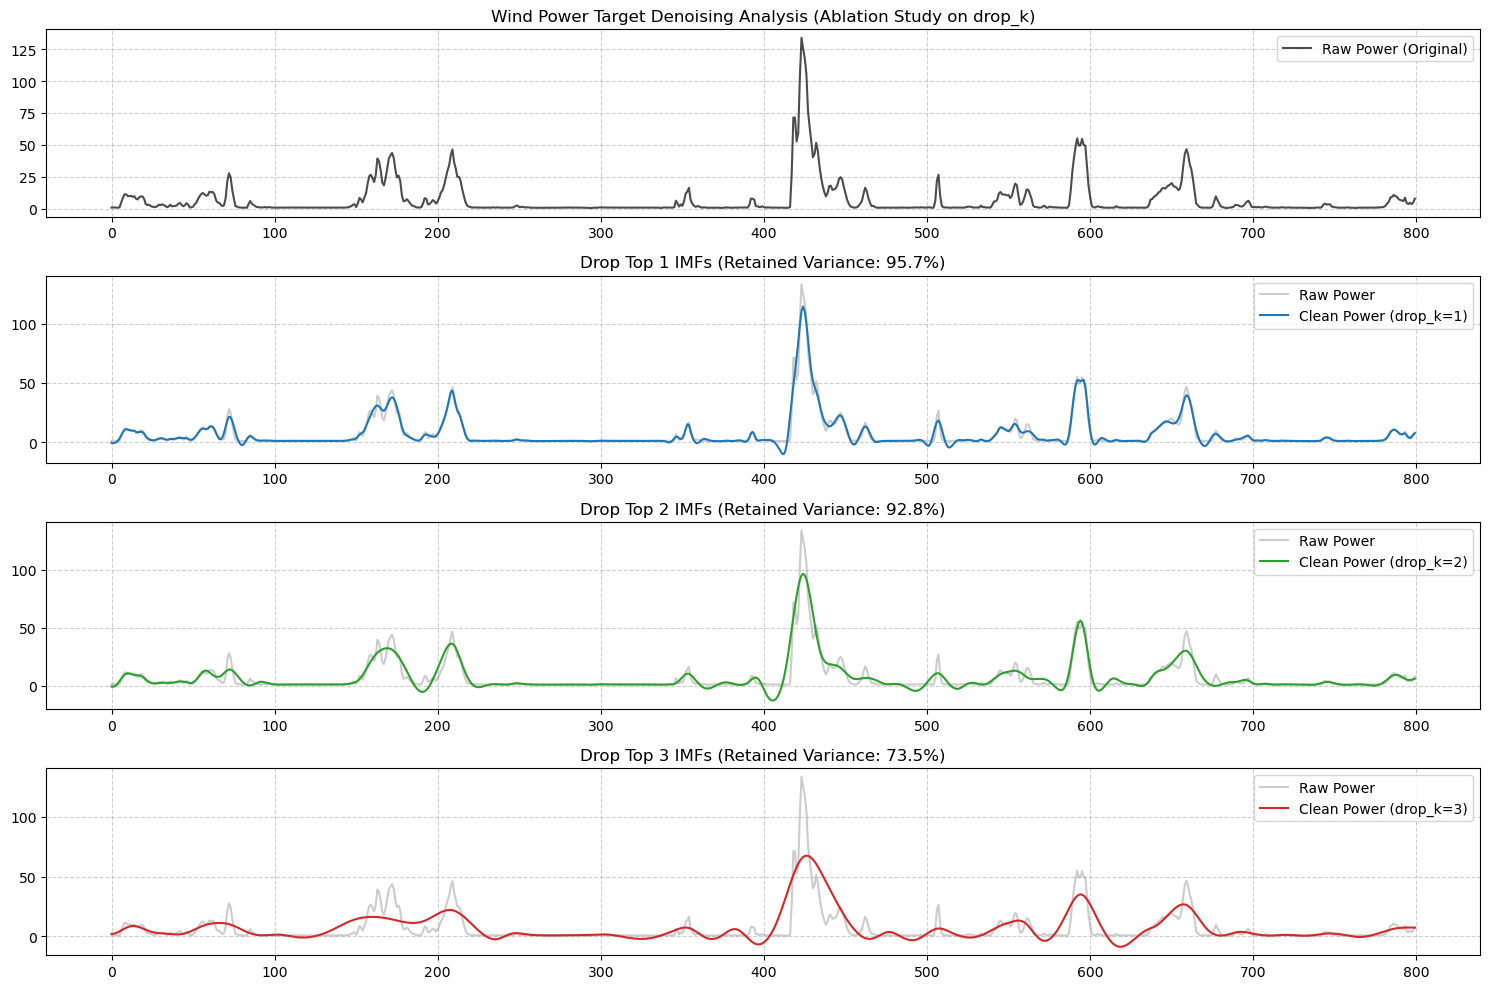

衍生特征构建完毕，最终特征维度: 31

--- 训练集目标去噪 ---
开始对目标功率进行 CEEMDAN 分解提纯...
共分解出 13 个 IMF 分量（含残差）。

--- 测试集目标去噪 ---
开始对目标功率进行 CEEMDAN 分解提纯...
共分解出 9 个 IMF 分量（含残差）。

🎉 数据处理与保存完成！
模型输入 X 形状: torch.Size([10272, 96, 31])
干净目标 Y 形状: torch.Size([10272, 1])


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.preprocessing import StandardScaler
from PyEMD import CEEMDAN
from joblib import dump


# ============================================
# 1 读取数据（支持选择数据量）
# ============================================

def load_data(file_path, data_size=None, start_index=0):
    data = pd.read_csv(file_path)

    if start_index > 0:
        data = data.iloc[start_index:]

    if data_size is not None:
        if len(data) > data_size:
            data = data.iloc[:data_size]

    print("数据尺寸:", data.shape, "\n数据起点:", start_index)

    # 检查并删除 NaN 值
    if data.isnull().values.any():
        print(f"警告：发现{data.isnull().sum().sum()}个 NaN 值，正在删除...")
        data = data.dropna()
        print("删除 NaN 后的数据尺寸:", data.shape)

    return data


# ============================================
# 2 时间序列划分（严格防泄露）
# ============================================

def time_series_split(data, split_rate=0.9):
    n = len(data)
    split_index = int(n * split_rate)

    train_data = data.iloc[:split_index].copy()
    test_data = data.iloc[split_index:].copy()

    print("训练集尺寸:", train_data.shape)
    print("测试集尺寸:", test_data.shape)

    return train_data, test_data, split_index


# ============================================
# 3 核心创新：目标变量 Y 去噪提纯
# ============================================

def ceemdan_denoise_target(power_series, drop_k=1):
    """
    使用 CEEMDAN 对功率目标进行离线去噪。
    drop_k: 剔除的高频噪声 IMF 数量（默认剔除 IMF0 ）和 IMF1
    """
    print("开始对目标功率进行 CEEMDAN 分解提纯...")

    ceemdan = CEEMDAN(trials=100, epsilon=0.005)
    imfs = ceemdan(power_series)

    # 打印分解出的总层数
    total_imfs = imfs.shape[0]
    print(f"共分解出 {total_imfs} 个 IMF 分量（含残差）。")

    if total_imfs <= drop_k:
        print("警告：分解层数过少，跳过去噪。")
        return power_series

    # 重构信号：舍弃前 drop_k 个高频噪声，将剩余的中低频 IMF 和残差求和
    clean_series = np.sum(imfs[drop_k:], axis=0)
    return clean_series


# ============================================
# 附加分析模块：可视化不同 drop_k 的去噪效果
# ============================================
def visualize_drop_k_experiments(power_series, display_length=500):
    """
    对比测试 drop_k = 1, 2, 3 时的信号重构效果
    """
    print(f"\n正在进行 CEEMDAN 分解用于可视化测试 (取前 {display_length} 个点)...")

    # 为了快速绘图，我们只取一段连续的数据进行分解分析
    sample_series = power_series[:display_length]
    ceemdan = CEEMDAN(trials=100, epsilon=0.005)
    imfs = ceemdan(sample_series)

    total_imfs = imfs.shape[0]
    print(f"该片段共分解出 {total_imfs} 个 IMF 分量。")

    plt.figure(figsize=(15, 10))

    # 1. 绘制原始数据的基准线
    plt.subplot(4, 1, 1)
    plt.plot(sample_series, label="Raw Power (Original)", color='black', alpha=0.7)
    plt.title("Wind Power Target Denoising Analysis (Ablation Study on drop_k)")
    plt.legend(loc="upper right")
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. 循环绘制 drop_k = 1, 2, 3 的效果
    colors = ['#1f77b4', '#2ca02c', '#d62728']  # 蓝，绿，红

    for k in range(1, 4):
        if total_imfs > k:
            # 舍弃前 k 个高频分量，重构剩余分量
            clean_series = np.sum(imfs[k:], axis=0)

            plt.subplot(4, 1, k + 1)
            plt.plot(sample_series, label="Raw Power", color='gray', alpha=0.4)
            plt.plot(clean_series, label=f"Clean Power (drop_k={k})", color=colors[k - 1], linewidth=1.5)

            # 计算平滑后的方差保留率 (用于量化去噪程度)
            var_raw = np.var(sample_series)
            var_clean = np.var(clean_series)
            retained_variance = (var_clean / var_raw) * 100

            plt.title(f"Drop Top {k} IMFs (Retained Variance: {retained_variance:.1f}%)")
            plt.legend(loc="upper right")
            plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


# ============================================
# 4 构建特征 (X 保持原始，Y 替换为纯净版)
# ============================================

def extract_features_and_targets(train_data, test_data):
    weather_cols = [
        '测风塔10m风速(m/s)', '测风塔30m风速(m/s)', '测风塔50m风速(m/s)',
        '测风塔70m风速(m/s)', '轮毂高度风速(m/s)', '测风塔10m风向(°)',
        '测风塔30m风向(°)', '测风塔50m风向(°)', '测风塔70m风向(°)',
        '轮毂高度风向(°)', '温度(°)', '气压(hPa)', '湿度(%)'
    ]

    # X：原始气象特征
    X_train_raw = train_data[weather_cols].values
    X_test_raw = test_data[weather_cols].values

    # Y_raw：保存原始功率
    y_train_raw = train_data['实际发电功率（mw）'].values
    y_test_raw = test_data['实际发电功率（mw）'].values

    # 🚨 修复：直接将 1 维的原始功率拼接到气象特征末尾
    # 不平铺成 24 列，因为后续的滑动窗口会自动帮我们把这 1 维展开成 96 步的历史轨迹
    X_train = np.hstack([X_train_raw, y_train_raw.reshape(-1, 1)])
    X_test = np.hstack([X_test_raw, y_test_raw.reshape(-1, 1)])

    def add_physics_features(data, data_index=None):
        feats = []

        # 1. 平均风速（5 个高度的平均）
        avg_wind = np.mean(data[:, :5], axis=1, keepdims=True)
        feats.append(avg_wind)

        # 2. 风速立方（捕捉 P ∝ v³关系）
        wind_cubed = data[:, :5] ** 3
        feats.append(wind_cubed)

        # 3. 风速标准差（表征风切变）
        wind_std = np.std(data[:, :5], axis=1, keepdims=True)
        feats.append(wind_std)

        # 4. 最大风速
        wind_max = np.max(data[:, :5], axis=1, keepdims=True)
        feats.append(wind_max)

        # 5. 风向一致性（计算风向的余弦相似度）
        direction_cols = data[:, 5:10]
        direction_cos = np.cos(np.deg2rad(direction_cols))
        direction_mean = np.mean(direction_cos, axis=1, keepdims=True)
        feats.append(direction_mean)

        # 6. 空气密度修正因子（温度、气压、湿度的综合影响）
        temp = data[:, 10]
        pressure = data[:, 11]
        humidity = data[:, 12]
        air_density_factor = (pressure / 1013.25) * (288.15 / (temp + 273.15))
        feats.append(air_density_factor.reshape(-1, 1))

        # 7. 风能密度近似值
        wind_power_density = 0.5 * air_density_factor * (avg_wind ** 3).flatten()
        feats.append(wind_power_density.reshape(-1, 1))

        # 8. 新增：时间周期特征（15 分钟数据的日内/周内周期）
        if data_index is not None:
            # 假设数据从某天的 00:00 开始
            hour_of_day = (data_index % 96) / 96 * 24  # 一天中的时刻
            day_of_week = (data_index // 96) % 7  # 一周中的第几天

            # 正弦编码时间周期
            time_sin = np.sin(2 * np.pi * hour_of_day / 24).reshape(-1, 1)
            time_cos = np.cos(2 * np.pi * hour_of_day / 24).reshape(-1, 1)
            dow_sin = np.sin(2 * np.pi * day_of_week / 7).reshape(-1, 1)
            dow_cos = np.cos(2 * np.pi * day_of_week / 7).reshape(-1, 1)

            feats.extend([time_sin, time_cos, dow_sin, dow_cos])
        
        # 9. 【新增】风切变指数（Wind Shear Exponent）- 风电行业标准公式
        # 使用对数风切变公式：α = ln(v2/v1) / ln(h2/h1)
        # 比简单的比值更稳定，且具有明确的物理意义
        v10 = data[:, 0]  # 10m 风速
        v70 = data[:, 3]  # 70m 风速
        v50 = data[:, 2]  # 50m 风速
        
        # 避免除以 0 或负数，使用绝对值并加小量
        alpha_70_10 = np.log(np.abs(v70) + 1e-5) / np.log(70/10) - np.log(np.abs(v10) + 1e-5) / np.log(70/10)
        alpha_50_10 = np.log(np.abs(v50) + 1e-5) / np.log(50/10) - np.log(np.abs(v10) + 1e-5) / np.log(50/10)
        
        # 过滤异常值：风切变指数通常在 -0.5 到 1.5 之间，超出范围的设为默认值 0.2
        alpha_70_10 = np.clip(alpha_70_10, -0.5, 1.5)
        alpha_50_10 = np.clip(alpha_50_10, -0.5, 1.5)
        
        feats.append(alpha_70_10.reshape(-1, 1))
        feats.append(alpha_50_10.reshape(-1, 1))
        
        return np.hstack([data] + feats)

    X_train = add_physics_features(X_train, data_index=np.arange(len(X_train)))
    X_test = add_physics_features(X_test, data_index=np.arange(len(X_test)))

    print(f"衍生特征构建完毕，最终特征维度: {X_train.shape[1]}")

    print("\n--- 训练集目标去噪 ---")
    y_train_clean = ceemdan_denoise_target(y_train_raw, drop_k=1)

    print("\n--- 测试集目标去噪 ---")
    y_test_clean = ceemdan_denoise_target(y_test_raw, drop_k=1)

    # 将形状调整为 (N, 1)
    y_train_clean = y_train_clean.reshape(-1, 1)
    y_test_clean = y_test_clean.reshape(-1, 1)
    y_test_raw = y_test_raw.reshape(-1, 1)  # 保留真实标签

    return X_train, X_test, y_train_clean, y_test_clean, y_test_raw


# ============================================
# 5 独立标准化
# 不用 StandardScaler 处理目标变量 Y，改用 MinMaxScaler。
# ============================================

from sklearn.preprocessing import StandardScaler, MinMaxScaler  # 引入 MinMaxScaler


def normalize_data(X_train, X_test, y_train, y_test, y_test_raw):
    scaler_x = StandardScaler()  # X 的气象特征依然用 StandardScaler，因为温度/气压等有正负且接近正态

    # 🚨 核心修复：Y 必须使用 MinMaxScaler，将其严格压缩在 0~1 之间
    scaler_y = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled = scaler_x.fit_transform(X_train)
    X_test_scaled = scaler_x.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train)
    y_test_scaled = scaler_y.transform(y_test)

    y_test_raw_scaled = scaler_y.transform(y_test_raw)

    dump(scaler_x, "scaler_x")
    dump(scaler_y, "scaler_y")

    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, y_test_raw_scaled

# ============================================
# 6 构造滑动窗口 (完美防泄露)
# ============================================

def build_windows(X_all, y_clean_all, y_raw_test, window_size, split_index):
    train_x, train_y_clean = [], []
    test_x, test_y_clean, test_y_raw = [], [], []

    for i in range(window_size, split_index):
        X_window = X_all[i - window_size:i]
        train_x.append(X_window)
        train_y_clean.append(y_clean_all[i])

    for i in range(split_index + window_size, len(X_all)):
        X_window = X_all[i - window_size:i]
        test_x.append(X_window)
        test_y_clean.append(y_clean_all[i])
        test_y_raw.append(y_raw_test[i - split_index])

    return (
        torch.tensor(np.array(train_x)).float(),
        torch.tensor(np.array(train_y_clean)).float(),
        torch.tensor(np.array(test_x)).float(),
        torch.tensor(np.array(test_y_clean)).float(),
        torch.tensor(np.array(test_y_raw)).float()
    )


# ============================================
# 主程序
# ============================================

if __name__ == "__main__":
    DATA_PATH = "wind_data.csv" # 每 15 分钟一个数据点
    START_INDEX = 0  # 数据起点
    DATA_SIZE = 11520
    WINDOW_SIZE = 96
    SPLIT_RATE = 0.9

    # Step 1 & 2: 加载与划分
    data = load_data(DATA_PATH, DATA_SIZE,START_INDEX)
    train_data, test_data, split_index = time_series_split(data, SPLIT_RATE)

    # 可视化不同 drop_k 的去噪效果，这里drop_k取1较佳
    train_power_for_plot = train_data['实际发电功率（mw）'].values
    visualize_drop_k_experiments(train_power_for_plot, display_length=800)

    # Step 3 & 4: 提取特征与目标去噪
    X_train, X_test, y_train_clean, y_test_clean, y_test_raw = extract_features_and_targets(train_data, test_data)

    # Step 5: 标准化
    X_train_s, X_test_s, y_train_s, y_test_s, y_test_raw_s = normalize_data(
        X_train, X_test, y_train_clean, y_test_clean, y_test_raw
    )

    # Step 6: 滑动窗口 (修复泄露问题)
    X_all = np.vstack((X_train_s, X_test_s))
    y_clean_all = np.vstack((y_train_s, y_test_s))

    train_set, train_label_clean, test_set, test_label_clean, test_label_raw = build_windows(
        X_all, y_clean_all, y_test_raw_s, WINDOW_SIZE, split_index
    )

    # Step 7: 保存数据
    dump(train_set, "train_set")
    dump(train_label_clean, "train_label")  # 模型训练的目标

    dump(test_set, "test_set")
    dump(test_label_clean, "test_label_clean")  # 用于评估模型对趋势的捕捉
    dump(test_label_raw, "test_label_raw")  # 用于评估模型在真实环境中的最终误差！

    print("\n🎉 数据处理与保存完成！")
    print("模型输入 X 形状:", train_set.shape)
    print("干净目标 Y 形状:", train_label_clean.shape)